# Predictive Maintenance System using NASA C-MAPSS Dataset

## Project Overview
This project focuses on predictive maintenance for aircraft turbofan engines using the NASA C-MAPSS dataset.

### Features
- Remaining Useful Life (RUL) prediction
- Engine degradation stage analysis
- Clustering and visualization
- Risk score estimation
- Maintenance alert generation
- Machine learning based predictive analytics

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib


In [ ]:
# #Download the Dataset
# #!pip install kagglehub
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("behrad3d/nasa-cmaps")

# print("Path to dataset files:", path)

# #Download the dataset and move into current directory with above folder name 'nasa-cmaps

✅ Phase 1: Clustering for Multi-Stage Failure Labeling

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset and define the column names
# Define column names based on CMAPSS documentation
column_names = ['engine_id', 'cycle', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3'] + \
               [f'sensor_{i}' for i in range(1, 22)]


In [32]:

# Read the training data (FD001 and FD003 assumed to be read as df1 and df2)
df1 = pd.read_csv('./data/train_FD001.txt', sep=' ' ,header=None)
df2 = pd.read_csv('./data/train_FD003.txt', sep=' ',header=None)  # Update path if needed
df1.drop(columns=[26, 27], inplace=True)  # remove empty columns at the end
df2.drop(columns=[26, 27], inplace=True)  # remove empty columns at the end
# Define column names (CMAPSS standard: 2 ID cols + 3 settings + 21 sensors = 26 total)
column_names = ['engine_id', 'cycle'] + \
               [f'setting_{i}' for i in range(1, 4)] + \
               [f'sensor_{i}' for i in range(1, 22)]

# Assign column names
df1.columns = column_names
df2.columns = column_names

# Combine into one DataFrame
df = pd.concat([df1, df2], ignore_index=True)
df.shape

(45351, 26)

## Data Loading & Preprocessing
This section loads the NASA C-MAPSS datasets and prepares the data for analysis and modeling.

In [33]:
#print Sample records for understanding
df.sample(5)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
32356,44,94,-0.0021,-0.0001,100.0,518.67,642.88,1592.88,1415.95,14.62,...,521.13,2388.14,8131.93,8.4659,0.03,395,2388,100.0,38.87,23.3235
25102,17,92,0.0006,0.0003,100.0,518.67,641.81,1580.76,1397.39,14.62,...,520.40,2387.95,8130.82,8.4299,0.03,391,2388,100.0,38.82,23.2558
36872,64,113,-0.0028,0.0005,100.0,518.67,642.48,1583.59,1400.50,14.62,...,522.17,2388.04,8161.14,8.3882,0.03,393,2388,100.0,38.77,23.2572
27124,24,180,0.0031,0.0004,100.0,518.67,642.60,1582.57,1397.51,14.62,...,519.34,2387.34,8121.77,8.3991,0.03,391,2388,100.0,38.66,23.2249
17547,86,208,-0.0003,0.0001,100.0,518.67,643.25,1596.17,1417.70,14.62,...,520.79,2388.13,8144.19,8.4721,0.03,395,2388,100.0,38.76,23.1731


🔹 Step 2: Data Preprocessing

In [34]:
# Original sensor columns
sensor_cols = df.columns[5:]
sensor_cols

Index(['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')

In [35]:

# Remove low-variance columns
low_var_cols = [col for col in sensor_cols if df[col].std() < 1e-2]
df_clean = df.drop(columns=low_var_cols)
# Define all valid sensor columns
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]

# Then safely compute low-variance sensors
low_var_cols = [col for col in sensor_cols if df[col].std() < 1e-2]

print("Low variance columns:", low_var_cols)


Low variance columns: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [36]:

# 🔧 FIX: Update sensor_cols to match cleaned data
sensor_cols = [col for col in sensor_cols if col not in low_var_cols]


In [37]:

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[sensor_cols])


In [38]:

# Create scaled DataFrame with correct column names
df_scaled = pd.DataFrame(X_scaled, columns=sensor_cols)
df_scaled['engine_id'] = df['engine_id']
df_scaled['cycle'] = df['cycle']
df_scaled

,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,engine_id,cycle
0,-1.409364,0.076860,-0.609157,0.516939,0.008780,-0.181018,-0.879150,-0.009516,-0.249785,-0.494425,-0.303479,0.042904,-0.506045,0.633235,0.514533,1,1
1,-0.780302,0.396965,-0.346968,0.516939,-0.212802,-0.338619,-0.980246,0.058909,-0.010049,-0.100730,-0.705813,0.261722,-0.506045,0.379640,0.546966,1,2
2,-0.399052,-0.181338,-0.237551,0.516939,-0.027545,-0.023417,-0.557263,-0.693769,0.044085,-0.415686,-0.607628,0.012661,-1.683495,0.168311,-0.012850,1,3
3,-0.399052,-0.966500,-0.478063,0.516939,0.041473,0.212984,-0.722260,-1.172747,0.214220,-0.021991,-0.573771,-0.869725,-0.506045,-0.127550,0.196552,1,4
4,-0.360928,-0.957441,-0.029039,0.516939,-0.121990,-0.181018,-0.451874,-0.659557,-0.044849,-0.336947,-0.575464,0.219026,0.082679,-0.043018,0.411595,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45346,2.326883,1.029624,1.817637,0.516939,-0.899342,1.316189,0.295381,2.727497,-1.023127,1.710266,-0.333950,1.539047,0.671404,-1.987245,-2.699822,100,148
45347,1.392821,1.085492,2.336854,0.516939,-0.899342,1.158588,-0.001232,2.248520,-0.926459,1.552788,0.020421,1.784550,1.260129,-1.733651,-2.618741,100,149
45348,2.441258,2.316083,2.571172,0.516939,-1.102762,1.316189,-0.056072,2.419583,-1.108195,1.237833,-0.454142,1.871721,1.848854,-2.198575,-1.958807,100,150
45349,2.631883,1.263663,2.071568,0.516939,-1.324344,1.394989,-0.114727,1.974819,-0.887792,1.395310,-0.155636,1.738296,1.260129,-2.536701,-1.908748,100,151


🔹 Step 3: KMeans Clustering into 5 Stages

In [39]:

# Fit KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled[sensor_cols])


In [40]:

# Preview cluster distribution
df_scaled['cluster'].value_counts().sort_index()


cluster
0    18413
1     4124
2    14107
3     6881
4     1826
Name: count, dtype: int64

## Exploratory Data Analysis
This section explores engine sensor behavior, operational settings, and degradation patterns.

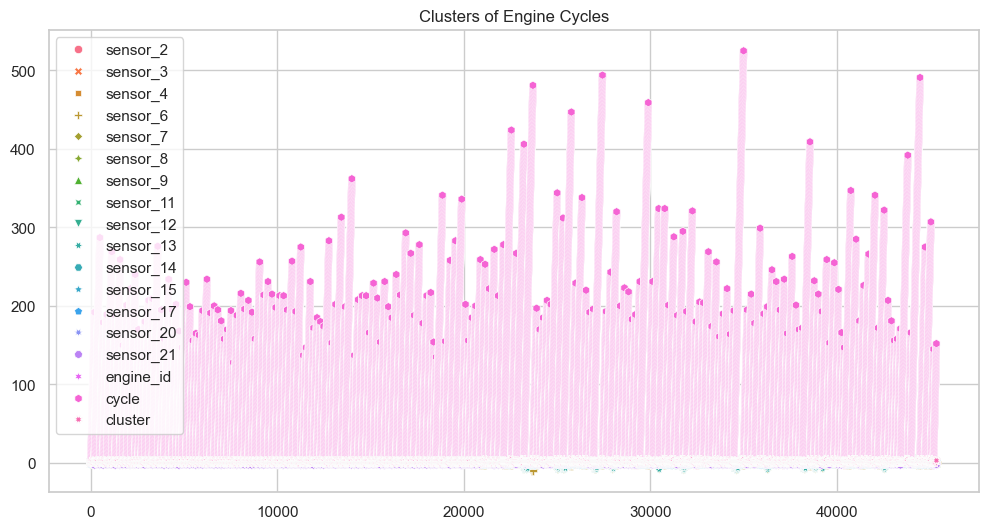

In [41]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')
various_clusters = df_scaled.groupby('cluster').mean()
various_clusters
# Plotting the clusters 
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style
sns.set(style="whitegrid")
# Set the figure size
plt.figure(figsize=(12, 6))
# Plot the clusters
sns.scatterplot(data=df_scaled)
plt.title('Clusters of Engine Cycles')


🔹 Step 4: Manual Cluster Mapping to Degradation Stages
We visually inspect and map clusters to:

Stage 0: Normal

Stage 1: Slightly Degraded

Stage 2: Moderately Degraded

Stage 3: Critical

Stage 4: Failure

In [42]:
# Manually map cluster number to ordered stages (you can update based on inspection)
cluster_to_stage = {
    3: 0,  # Normal
    2: 1,  # Slightly Degraded
    0: 2,  # Moderately Degraded
    1: 3,  # Critical
    4: 4   # Failure
}

df_scaled['stage'] = df_scaled['cluster'].map(cluster_to_stage)


In [43]:
df_scaled

,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,engine_id,cycle,cluster,stage
0,-1.409364,0.076860,-0.609157,0.516939,0.008780,-0.181018,-0.879150,-0.009516,-0.249785,-0.494425,-0.303479,0.042904,-0.506045,0.633235,0.514533,1,1,2,1
1,-0.780302,0.396965,-0.346968,0.516939,-0.212802,-0.338619,-0.980246,0.058909,-0.010049,-0.100730,-0.705813,0.261722,-0.506045,0.379640,0.546966,1,2,0,2
2,-0.399052,-0.181338,-0.237551,0.516939,-0.027545,-0.023417,-0.557263,-0.693769,0.044085,-0.415686,-0.607628,0.012661,-1.683495,0.168311,-0.012850,1,3,2,1
3,-0.399052,-0.966500,-0.478063,0.516939,0.041473,0.212984,-0.722260,-1.172747,0.214220,-0.021991,-0.573771,-0.869725,-0.506045,-0.127550,0.196552,1,4,2,1
4,-0.360928,-0.957441,-0.029039,0.516939,-0.121990,-0.181018,-0.451874,-0.659557,-0.044849,-0.336947,-0.575464,0.219026,0.082679,-0.043018,0.411595,1,5,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45346,2.326883,1.029624,1.817637,0.516939,-0.899342,1.316189,0.295381,2.727497,-1.023127,1.710266,-0.333950,1.539047,0.671404,-1.987245,-2.699822,100,148,3,0
45347,1.392821,1.085492,2.336854,0.516939,-0.899342,1.158588,-0.001232,2.248520,-0.926459,1.552788,0.020421,1.784550,1.260129,-1.733651,-2.618741,100,149,3,0
45348,2.441258,2.316083,2.571172,0.516939,-1.102762,1.316189,-0.056072,2.419583,-1.108195,1.237833,-0.454142,1.871721,1.848854,-2.198575,-1.958807,100,150,3,0
45349,2.631883,1.263663,2.071568,0.516939,-1.324344,1.394989,-0.114727,1.974819,-0.887792,1.395310,-0.155636,1.738296,1.260129,-2.536701,-1.908748,100,151,3,0


🔹 Step 5: PCA Visualization of Clusters

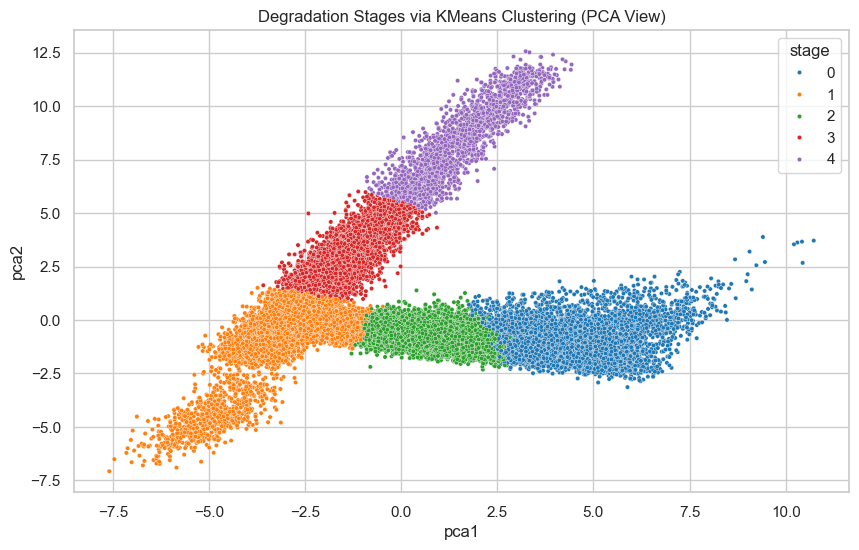

In [44]:


# Reduce to 2D using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[sensor_cols])
df_scaled['pca1'] = pca_result[:, 0]
df_scaled['pca2'] = pca_result[:, 1]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scaled, x='pca1', y='pca2', hue='stage', palette='tab10', s=10)
plt.title('Degradation Stages via KMeans Clustering (PCA View)')
plt.show()


 🔹 Step 6: t-SNE Visualization

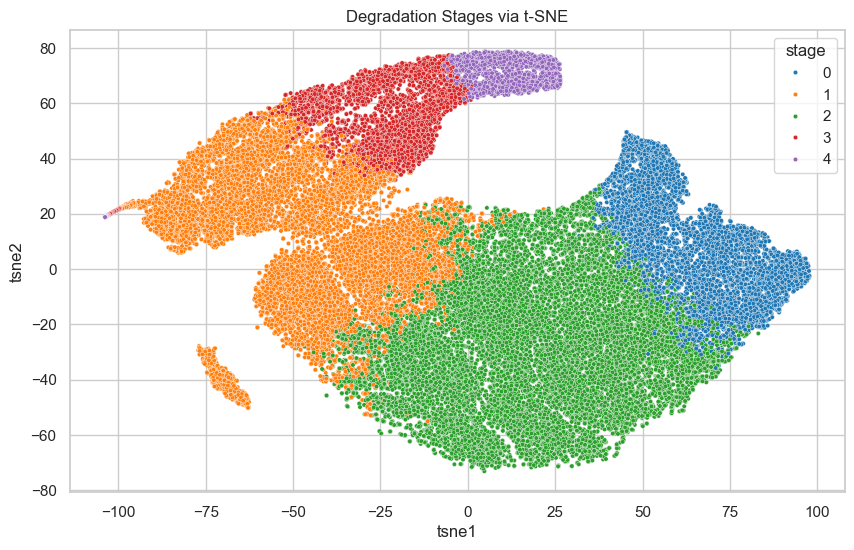

In [45]:

# t-SNE for nonlinear cluster view
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_result = tsne.fit_transform(df_scaled[sensor_cols])
df_scaled['tsne1'] = tsne_result[:, 0]
df_scaled['tsne2'] = tsne_result[:, 1]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scaled, x='tsne1', y='tsne2', hue='stage', palette='tab10', s=10)
plt.title('Degradation Stages via t-SNE')
plt.show()


# Training and Clustering done for phase 1. 
Now performing testing optional as not asked in assignment. 

# Step 1 Read the Training Dataset

In [46]:
# Load the test dataset and define the column names
test_df = pd.read_csv(f'./data/test_FD001.txt', sep=' ', header=None)
test_df.drop(columns=[26, 27], inplace=True)  # drop empty cols

test_df.columns = ['engine_id', 'cycle', 'operational_setting_1', 'operational_setting_2', 'operational_setting_3'] + \
                    [f'sensor_{i}' for i in range(1, 22)]

test_df.head()


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


# Step 2: Preprocess Test Data (Same as Train)


In [47]:
# Drop same low-variance columns
test_df_clean = test_df.drop(columns=low_var_cols)

# Use the same sensor columns as in training
test_sensor_data = test_df_clean[sensor_cols]

# Normalize using same scaler
X_test_scaled = scaler.transform(test_sensor_data)

# Create scaled DataFrame
test_scaled_df = pd.DataFrame(X_test_scaled, columns=sensor_cols)
test_scaled_df['engine_id'] = test_df['engine_id']
test_scaled_df['cycle'] = test_df['cycle']


## Feature Engineering
This section creates features useful for predictive maintenance and Remaining Useful Life prediction.

# Step 3 Apply Trained Clustering Model (KMeans)

In [48]:
# Predict cluster labels using trained KMeans
test_scaled_df['cluster'] = kmeans.predict(test_scaled_df[sensor_cols])

# Map clusters to degradation stages
test_scaled_df['stage'] = test_scaled_df['cluster'].map(cluster_to_stage)

test_scaled_df.head()


,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,engine_id,cycle,cluster,stage
0,0.878134,-0.589018,-0.855862,0.516939,-0.158314,-0.338619,-0.689355,-0.933258,-0.226585,-0.415686,-1.040998,-0.211493,-0.506045,-0.212081,0.193732,1,1,0,2
1,-1.619052,-0.111881,-1.143857,0.516939,0.186772,-0.575020,-0.486686,0.093122,-0.056449,-0.179469,-0.247050,-0.654465,0.082679,0.464172,0.321348,1,2,2,1
2,-0.189365,-0.339880,-0.532771,0.516939,-0.082032,-0.259818,-0.365561,0.093122,-0.129917,-0.415686,-0.784249,0.480540,0.082679,0.717767,0.497612,1,3,0,2
3,-0.227490,-0.765680,-0.008394,0.516939,-0.096562,-0.417419,-0.922068,-0.659557,-0.358053,-0.258208,-0.626249,-0.451659,-1.094770,0.379640,0.195142,1,4,2,1
4,-0.094053,-0.302132,-0.472901,0.516939,-0.063870,-0.575020,-0.957356,-0.556919,-0.060316,-0.415686,-0.815849,-0.248852,-1.683495,0.337374,0.472230,1,5,2,1


# Step 4 (Optional): Evaluate with True RUL

In [49]:
# Load actual RUL for last cycle of each engine
rul_truth = pd.read_csv('./data/RUL_FD001.txt', sep=' ', header=None)
rul_truth = rul_truth[0]

# You can compare with predicted RUL (if you did regression)
# Not required if only testing health stage clustering


# Step 5 Visualize Test Results

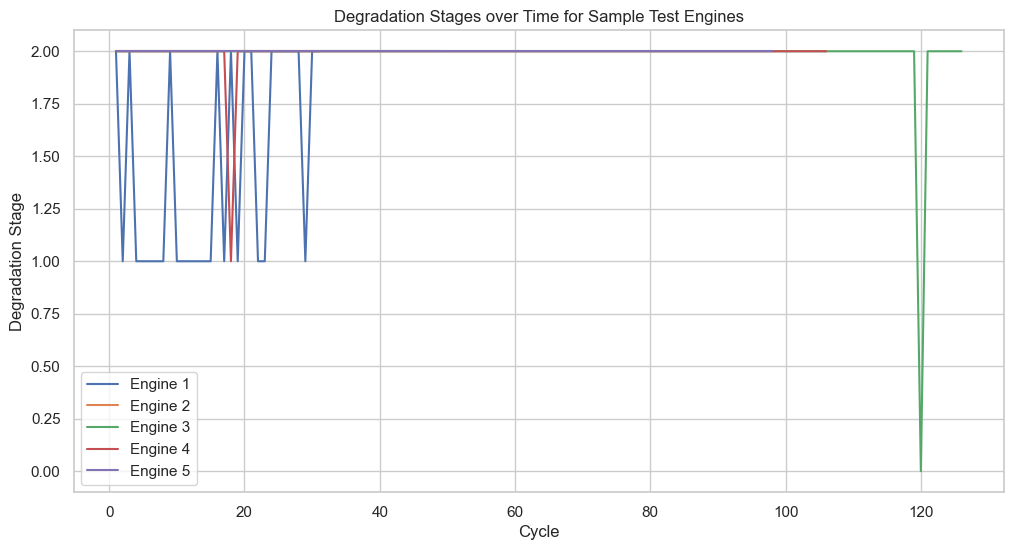

In [50]:
plt.figure(figsize=(12, 6))
sample_engines = test_scaled_df['engine_id'].unique()[:5]

for eid in sample_engines:
    engine_data = test_scaled_df[test_scaled_df['engine_id'] == eid]
    plt.plot(engine_data['cycle'], engine_data['stage'], label=f'Engine {eid}')

plt.xlabel("Cycle")
plt.ylabel("Degradation Stage")
plt.title("Degradation Stages over Time for Sample Test Engines")
plt.legend()
plt.grid(True)
plt.show()

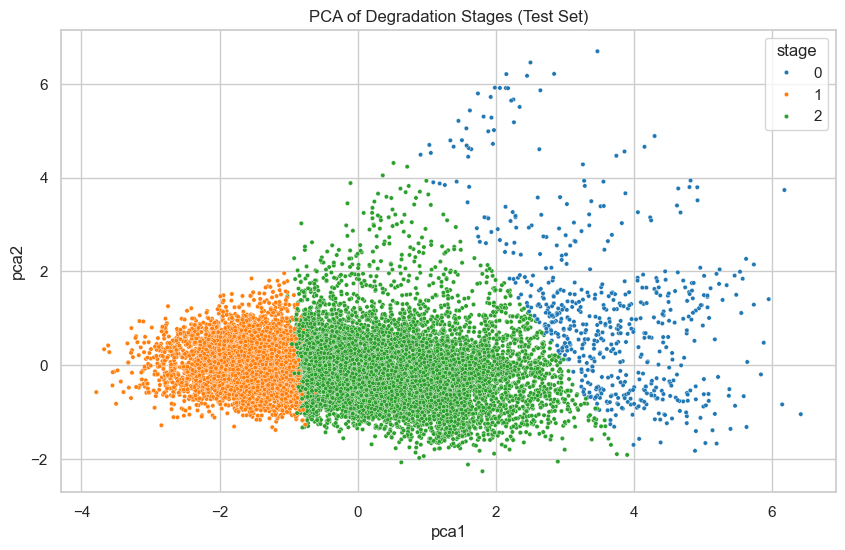

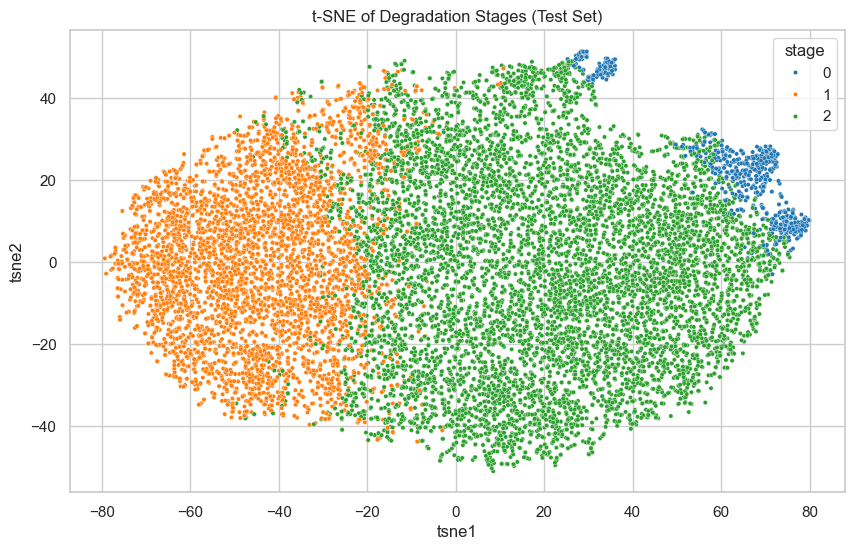

In [51]:
# -----------------------------------------
# Step 6: PCA Visualization
# -----------------------------------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_scaled_df[sensor_cols])
test_scaled_df['pca1'] = pca_result[:, 0]
test_scaled_df['pca2'] = pca_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_scaled_df, x='pca1', y='pca2', hue='stage', palette='tab10', s=10)
plt.title('PCA of Degradation Stages (Test Set)')
plt.grid(True)
plt.show()

# -----------------------------------------
# Step 7: t-SNE Visualization
# -----------------------------------------
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_result = tsne.fit_transform(test_scaled_df[sensor_cols])
test_scaled_df['tsne1'] = tsne_result[:, 0]
test_scaled_df['tsne2'] = tsne_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_scaled_df, x='tsne1', y='tsne2', hue='stage', palette='tab10', s=10)
plt.title('t-SNE of Degradation Stages (Test Set)')
plt.grid(True)
plt.show()


# Function Set for Phase 2 - Classification

In [ ]:
!pip3 install imblearn

In [90]:
#!pip3 install xgboost
# brew install libomp to support xgboost

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from imblearn.over_sampling import SMOTE
#pip install xgboost

In [53]:
# Data Preparation for ML
def prepare_data(df, feature_cols, target_col='stage', test_size=0.2):
    X = df[feature_cols]
    y = df[target_col]
    return train_test_split(X, y, stratify=y, test_size=test_size, random_state=42)


## Clustering & Pattern Analysis
This phase groups engines based on operational and degradation characteristics.

In [54]:
# Random Forest Classifier
def train_random_forest(X_train, y_train):
    clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    return clf


In [55]:
# Logistic Regression Classifier
def train_logistic_regression(X_train, y_train):
    clf = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                             class_weight='balanced', max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    return clf


In [56]:
# Support Vector Machine Classifier , SVM
def train_svm(X_train, y_train):
    clf = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    clf.fit(X_train, y_train)
    return clf


In [57]:
# Evaluation Function for classifiers and confusion matrix
def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)
    return report, conf_matrix, y_pred


In [58]:
# Function to plot confusion matrix

def plot_confusion_matrix(conf_matrix, class_labels=[0, 1, 2, 3, 4], title="Confusion Matrix"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [59]:
# Function to plot feature importance
def get_feature_importance(model, feature_names, top_n=10):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
        return imp_df.sort_values(by='importance', ascending=False).head(top_n)
    else:
        print("Model does not support feature_importances_")
        return None


In [60]:
# Function to plot feature importance
def add_rolling_features(df, sensor_cols, window=5):
    df_rolled = df.copy()
    for sensor in sensor_cols:
        df_rolled[f'{sensor}_mean'] = df_rolled.groupby('engine_id')[sensor].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        df_rolled[f'{sensor}_std'] = df_rolled.groupby('engine_id')[sensor].transform(lambda x: x.rolling(window=window, min_periods=1).std().fillna(0))
    return df_rolled


In [61]:
# Function to apply SMOTE for balancing classes
def apply_smote(X, y):
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res


# Test the above function steps. 

In [62]:
# Prepare data
df_clustered = df_scaled  # rename actual variable is

X_train, X_test, y_train, y_test = prepare_data(df_clustered, sensor_cols)


In [63]:

# Train all models
rf_model = train_random_forest(X_train, y_train)
lr_model = train_logistic_regression(X_train, y_train)
svm_model = train_svm(X_train, y_train)


Random Forest Classification Report:
              precision    recall  f1-score      support
0              0.977695  0.955669  0.966556  1376.000000
1              0.964110  0.970943  0.967514  2822.000000
2              0.965952  0.978279  0.972076  3683.000000
3              0.972152  0.930909  0.951084   825.000000
4              0.986264  0.983562  0.984911   365.000000
accuracy       0.968471  0.968471  0.968471     0.968471
macro avg      0.973234  0.963872  0.968428  9071.000000
weighted avg   0.968541  0.968471  0.968427  9071.000000


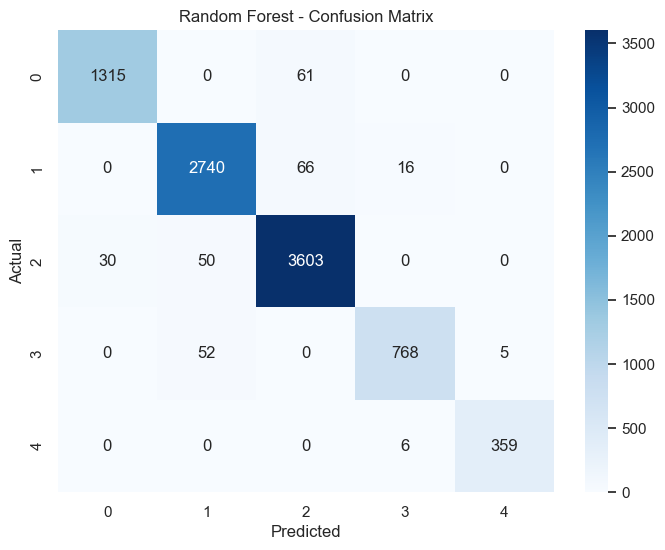


Logistic Regression Classification Report:
              precision    recall  f1-score      support
0              0.988506  1.000000  0.994220  1376.000000
1              0.992903  0.991495  0.992199  2822.000000
2              0.998358  0.990225  0.994275  3683.000000
3              0.978520  0.993939  0.986170   825.000000
4              0.986486  1.000000  0.993197   365.000000
accuracy       0.992834  0.992834  0.992834     0.992834
macro avg      0.988955  0.995132  0.992012  9071.000000
weighted avg   0.992884  0.992834  0.992840  9071.000000


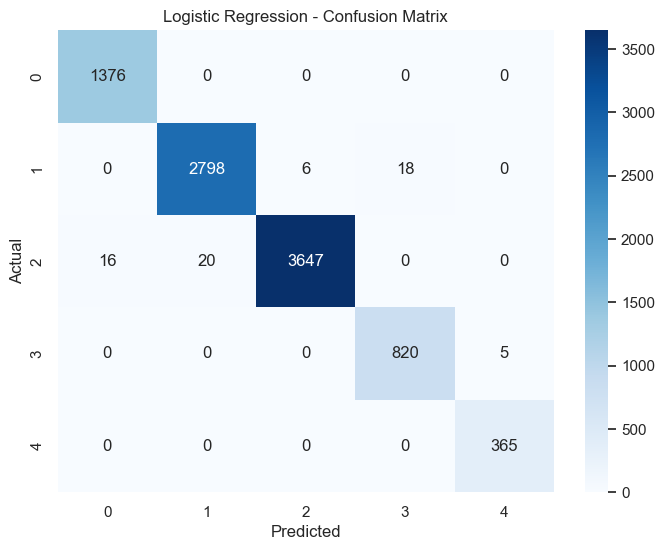


SVM Classification Report:
              precision    recall  f1-score      support
0              0.967651  1.000000  0.983560  1376.000000
1              0.990409  0.987952  0.989179  2822.000000
2              0.997789  0.980179  0.988906  3683.000000
3              0.969267  0.993939  0.981448   825.000000
4              0.986486  1.000000  0.993197   365.000000
accuracy       0.987653  0.987653  0.987653     0.987653
macro avg      0.982320  0.992414  0.987258  9071.000000
weighted avg   0.987872  0.987653  0.987674  9071.000000


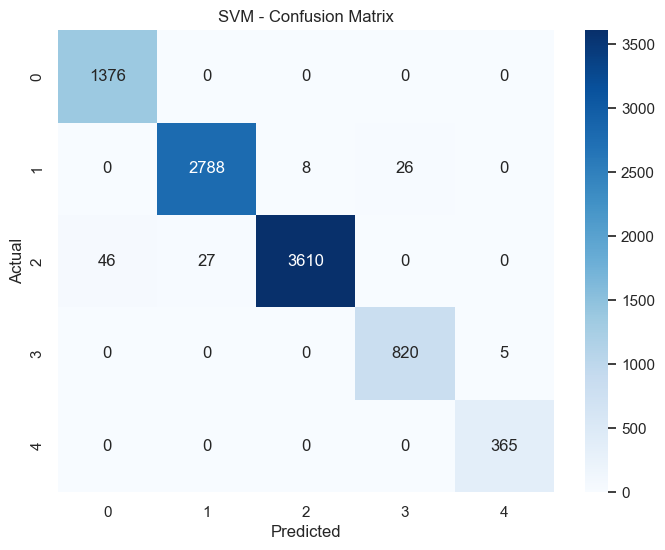

In [64]:
# Evaluate
for model, name in zip([rf_model, lr_model, svm_model], ['Random Forest', 'Logistic Regression', 'SVM']):
    report, conf_matrix, _ = evaluate_classifier(model, X_test, y_test)
    print(f"\n{name} Classification Report:")
    print(pd.DataFrame(report).transpose())
    plot_confusion_matrix(conf_matrix, title=f"{name} - Confusion Matrix")

## Machine Learning Models
This section trains predictive models for estimating engine health and failure risk.

In [65]:
from xgboost import XGBClassifier

# train with xgboost
def train_xgboost_classifier(X_train, y_train):
    """
    Trains an XGBoost classifier with class imbalance handling.
    """
    model = XGBClassifier(
        objective='multi:softmax',       # For multi-class classification
        num_class=5,                     # 5 stages: 0 to 4
        eval_metric='mlogloss',          # Multiclass log loss
        use_label_encoder=False,
        scale_pos_weight=1,              # Optional: can be tuned or class-weighted manually
        max_depth=6,
        learning_rate=0.1,
        n_estimators=100,
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

In [66]:
#Convert y_train to int
y_train = y_train.astype(int)


In [ ]:
xgb_model = train_xgboost_classifier(X_train, y_train)


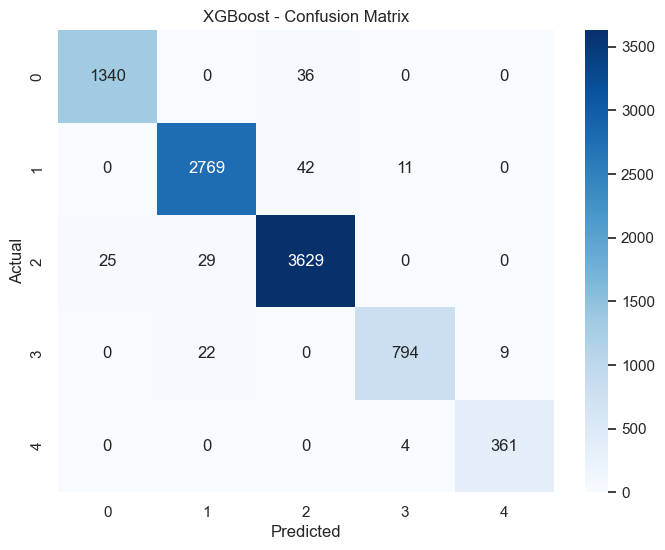

In [68]:
# Predict and evaluate
report, conf_matrix, y_pred = evaluate_classifier(xgb_model, X_test, y_test)

# Visualize confusion matrix
plot_confusion_matrix(conf_matrix, title="XGBoost - Confusion Matrix")



 # Phase 3 Function Set

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [70]:
# Label Creation – Time to Next Stage
def create_time_to_next_stage_labels(df, stage_col='stage', engine_col='engine_id', cycle_col='cycle'):
    """
    Assigns for each row the number of cycles until the next higher degradation stage.
    """
    df = df.sort_values(by=[engine_col, cycle_col]).copy()
    df['time_to_next_stage'] = np.nan

    for eid in df[engine_col].unique():
        engine_df = df[df[engine_col] == eid]
        for idx, row in engine_df.iterrows():
            current_stage = row[stage_col]
            current_cycle = row[cycle_col]
            next_stage_df = engine_df[
                (engine_df[cycle_col] > current_cycle) & 
                (engine_df[stage_col] > current_stage)
            ]
            if not next_stage_df.empty:
                next_stage_cycle = next_stage_df.iloc[0][cycle_col]
                df.at[idx, 'time_to_next_stage'] = next_stage_cycle - current_cycle
            else:
                df.at[idx, 'time_to_next_stage'] = np.nan  # You can also assign 0 or max value
    return df.dropna(subset=['time_to_next_stage'])


In [71]:
# Model Trainer (RF, Ridge, SVR)

def train_regression_model(X_train, y_train, model_type='rf'):
    """
    Train a regression model to predict time to next degradation stage.
    model_type: 'rf' | 'ridge' | 'svr'
    """
    if model_type == 'rf':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    elif model_type == 'ridge':
        model = Ridge(alpha=1.0)
    elif model_type == 'svr':
        model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    else:
        raise ValueError("Unsupported model_type. Use 'rf', 'ridge', or 'svr'.")
    
    model.fit(X_train, y_train)
    return model

In [72]:
# Regression Evaluation
def evaluate_regression_model(model, X_test, y_test):
    """
    Evaluate model predictions using RMSE, MAE, and R² Score.
    """
    y_pred = model.predict(X_test)
    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2 Score': r2_score(y_test, y_pred)
    }
    return metrics, y_pred

In [73]:
# 1. Prepare data (replace sample_df with df_clustered)
df_labeled = create_time_to_next_stage_labels(df_clustered)

In [74]:

# 2. Choose features
features = [col for col in df_labeled.columns if 'sensor' in col] + ['stage']
X = df_labeled[features]
y = df_labeled['time_to_next_stage']

In [75]:

# 3. Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Risk Scoring & Maintenance Alerts
This section computes risk scores and generates maintenance alerts based on model predictions.

In [76]:

# 4. Train
model = train_regression_model(X_train, y_train, model_type='rf')


In [78]:

# 5. Evaluate
metrics, predictions = evaluate_regression_model(model, X_test, y_test)
print(metrics)

#Lower RMSE = better performance.
#Lower MAE = better.
#Higher R² = better.
# 1.0 = perfect prediction
# 0.0 = model predicts no better than the mean
# Negative = worse than baseline

{'RMSE': np.float64(42.339325146423214), 'MAE': 23.447076363636363, 'R2 Score': 0.43437740794471935}


In [79]:
def plot_regression_predictions(y_true, y_pred, title='Predicted vs Actual Time to Next Stage', figsize=(10, 6)):
    """
    Plot predicted vs actual values for regression results.
    
    Parameters:
    - y_true: array-like, true values
    - y_pred: array-like, predicted values
    - title: str, title of the plot
    - figsize: tuple, figure size
    """
    plt.figure(figsize=figsize)
    plt.scatter(y_true, y_pred, alpha=0.6, color='blue', edgecolor='k', label='Predicted')
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal (y = x)')
    plt.xlabel('Actual Time to Next Stage')
    plt.ylabel('Predicted Time to Next Stage')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

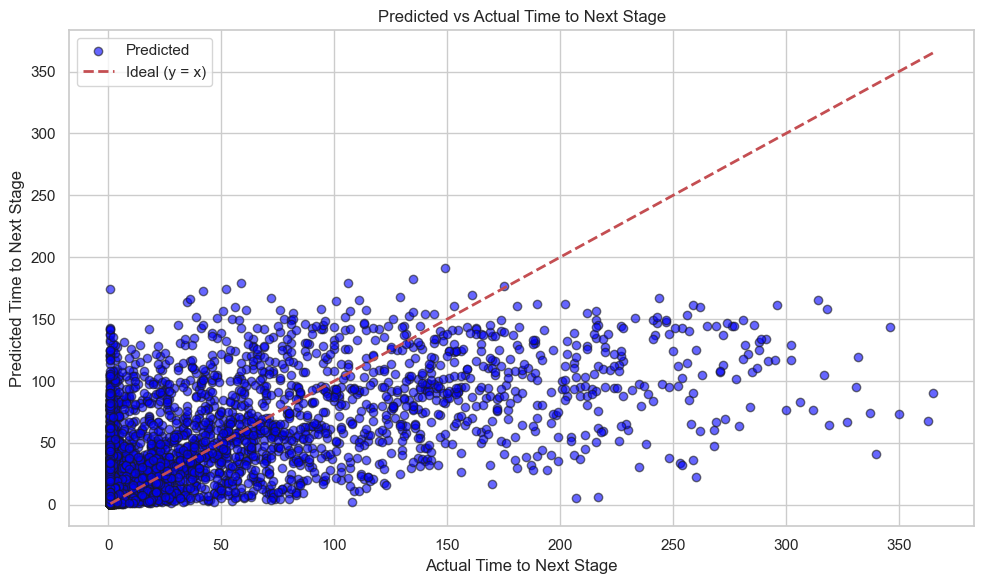

In [80]:
# After training and evaluation
metrics, y_pred = evaluate_regression_model(model, X_test, y_test)
plot_regression_predictions(y_test, y_pred)


# Phase 4: Compute Risk Score and Decision Logic

In [81]:
# ----------------------------
def compute_risk_score_from_models_v2(classifier, regressor, X_data_clf, X_data_reg, method='minmax', min_score=0, max_score=60, stage_index=4):
    failure_probs = classifier.predict_proba(X_data_clf)[:, stage_index]
    time_to_failure = regressor.predict(X_data_reg)
    
    if method == 'minmax':
        raw_scores = failure_probs * time_to_failure
        risk_scores = (raw_scores - min_score) / (max_score - min_score + 1e-6)
    elif method == 'inversion':
        risk_scores = failure_probs / (time_to_failure + 1e-6)
    else:
        raise ValueError("Unsupported method.")
    
    return pd.DataFrame({
        'failure_probability': failure_probs,
        'predicted_time_to_failure': time_to_failure,
        'risk_score': risk_scores
    })


In [82]:

def maintenance_alerts(risk_scores, threshold=0.7):
    for idx, score in enumerate(risk_scores):
        if score > threshold:
            print(f"⚠️ Maintenance Alert: Risk Score = {score:.3f} at index {idx}")


In [83]:

def plot_risk_trend_over_time(df, engine_col='engine_id', cycle_col='cycle', risk_col='risk_score'):
    plt.figure(figsize=(12, 6))
    for eid in df[engine_col].unique():
        subset = df[df[engine_col] == eid]
        plt.plot(subset[cycle_col], subset[risk_col], label=f'Engine {eid}')
    plt.xlabel("Cycle")
    plt.ylabel("Risk Score")
    plt.title("Risk Score Over Time per Engine")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [84]:

# Simulate labeled_df if not already available
np.random.seed(42)
sample_df = pd.DataFrame({
    'engine_id': np.repeat(np.arange(1, 6), 50),
    'cycle': list(range(1, 51)) * 5,
    'stage': np.random.choice([0, 1, 2, 3, 4], size=250, p=[0.4, 0.25, 0.2, 0.1, 0.05]),
    'sensor_1': np.random.normal(100, 5, 250),
    'sensor_2': np.random.normal(200, 10, 250)
})


In [85]:

# Generate time-to-next-stage labels
def create_time_to_next_stage_labels(df):
    df = df.sort_values(by=['engine_id', 'cycle']).copy()
    df['time_to_next_stage'] = np.nan
    for eid in df['engine_id'].unique():
        edf = df[df['engine_id'] == eid]
        for idx, row in edf.iterrows():
            cur_stage = row['stage']
            cur_cycle = row['cycle']
            next_df = edf[(edf['cycle'] > cur_cycle) & (edf['stage'] > cur_stage)]
            if not next_df.empty:
                df.at[idx, 'time_to_next_stage'] = next_df.iloc[0]['cycle'] - cur_cycle
            else:
                df.at[idx, 'time_to_next_stage'] = np.nan
    return df.dropna(subset=['time_to_next_stage'])

labeled_df = create_time_to_next_stage_labels(sample_df)
labeled_df['stage'] = labeled_df['stage'].astype(int)


In [86]:


if 4 not in labeled_df['stage'].unique():
    synthetic = labeled_df.sample(10, replace=True).copy()
    synthetic['stage'] = 4
    synthetic['sensor_1'] += np.random.normal(0, 2, size=10)
    synthetic['sensor_2'] += np.random.normal(0, 2, size=10)
    synthetic['time_to_next_stage'] = np.random.randint(5, 60, size=10)
    labeled_df = pd.concat([labeled_df, synthetic], ignore_index=True)


## Visualization & Insights
This section visualizes trends, degradation patterns, and maintenance insights.

In [87]:


features_clf = ['sensor_1', 'sensor_2']
features_reg = ['sensor_1', 'sensor_2', 'stage']

X_all_clf = labeled_df[features_clf]
X_all_reg = labeled_df[features_reg]
y_all_clf = labeled_df['stage']
y_all_reg = labeled_df['time_to_next_stage']

X_train_clf, X_test_clf, y_train_clf, y_test_clf, X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_all_clf, y_all_clf, X_all_reg, y_all_reg, test_size=0.2, random_state=42
)


In [88]:


rf_model_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_clf.fit(X_train_clf, y_train_clf)

rf_model_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_reg.fit(X_train_reg, y_train_reg)

stage_index = rf_model_clf.classes_.tolist().index(4)


In [89]:


risk_df = compute_risk_score_from_models_v2(
    classifier=rf_model_clf,
    regressor=rf_model_reg,
    X_data_clf=X_test_clf,
    X_data_reg=X_test_reg,
    method='minmax',
    min_score=0,
    max_score=60,
    stage_index=stage_index
)

maintenance_alerts(risk_df['risk_score'], threshold=0.7)


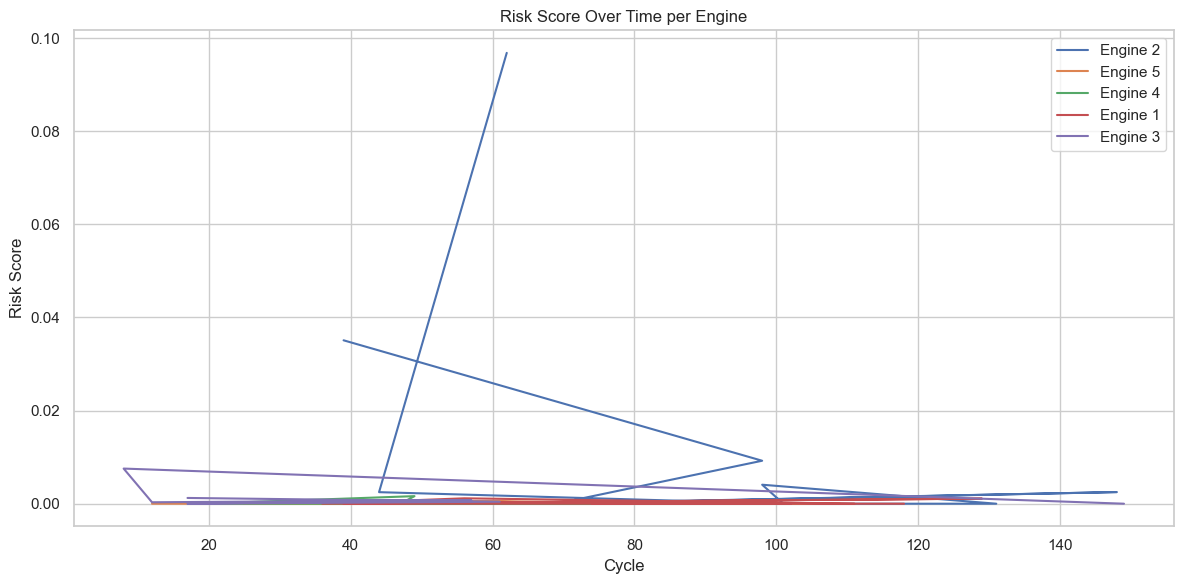

In [90]:
# Add fake cycle + engine_id for plotting
risk_df['engine_id'] = np.random.choice([1, 2, 3, 4, 5], size=len(risk_df))
risk_df['cycle'] = np.random.randint(1, 150, size=len(risk_df))

plot_risk_trend_over_time(risk_df)
